<a href="https://colab.research.google.com/github/vedant-sangrame/Machine-Learning-TAE1/blob/main/ML_TAE1_Model_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name: Swayash Mahajan**

**Topic: Accident Severity Prediction**

**Model: 5) SVC**

Mounted at /content/drive
SVC Accuracy: 0.6186716722795782


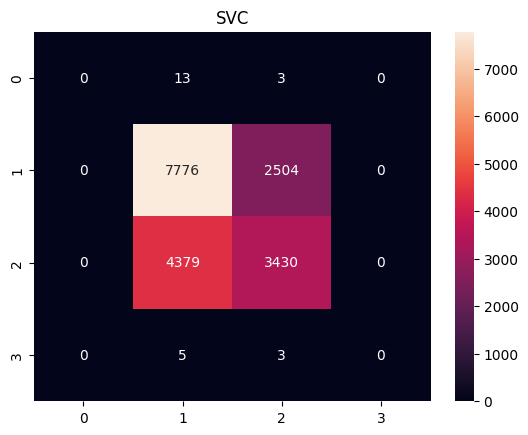

In [ ]:
# ================== STEP 1 ==================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.svm import SVC

from google.colab import drive
drive.mount('/content/drive')

# ================== STEP 2 ==================
path = "/content/drive/MyDrive/ML_dataset/US_Accidents_March23.csv"
df = pd.read_csv(path, nrows=150000)

# ================== STEP 3 ==================
df.drop_duplicates(inplace=True)

data = df[['Severity','Start_Lat','Start_Lng','Distance(mi)',
           'Temperature(F)','Humidity(%)','Pressure(in)',
           'Visibility(mi)','Wind_Speed(mph)']]

data = data.dropna()

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
data = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]

# ================== STEP 4 ==================
X = data.drop('Severity', axis=1)
y = data['Severity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================== STEP 5 ==================
model = SVC(kernel='rbf')
model.fit(X_train, y_train)

# ================== STEP 6 ==================
y_pred = model.predict(X_test)

# ================== STEP 7 ==================
print("SVC Accuracy:", accuracy_score(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("SVC")
plt.show()